**A synthetic observability walkthrough, part 1 — a portfolio starting point, not production.**

This notebook builds a small teacher–student regression task whose latent truth is known row by row, fits its preprocessing on training rows only, runs seeded experiments, and then studies three things a training-dynamics review actually needs: a no-hindsight online diagnosis, a paired-seed audit, and an incident accounting that keeps abstentions visible.

Everything here is synthetic: no data is downloaded, no API is called, and no number is a production guarantee. Time budget: a few minutes locally on CPU.

Project choice (derived here, not specified by the papers): the teacher, the noise schedule, the regime names, the incident traces and the detector thresholds are chosen here. The three papers give order-level statements, and nothing below promotes one into an exact constant. Every stochastic step is seeded and every artifact is content-hashed, so the same seed plus the same config reproduces the same hash values on a re-run.

## Data understanding

The task is a **teacher–student regression with a known latent truth**. Each of the 320 rows carries six observable features `x0..x5`, a target `y`, and five latent truth columns that the pipeline never uses as inputs: `latent_teacher_score`, `latent_signal`, `noise`, `noise_sigma` and `regime`.

- `y = x . w_star + 0.8 * (mean_j cos(x_j) - exp(-1/2)) + noise`, and the per-row noise scale is set by the latent margin `|x . w_star|`.
- `w_star` is the known optimum of the linear part and is published with the data, so a decision made without hindsight can later be checked against an answer that was always there.
- Regimes are named by margin relative to the noise scale: `comfortable_margin` (easy), `boundary_margin` (ambiguous: the signal and the noise are the same size, so one run cannot separate them) and `low_margin_high_noise` (hard: margin below 0.3 sigma, with 1.5x the noise).
- `signal_strength` is the planted-signal share of the target variance and sits strictly between 0 and 1; the remainder is irreducible noise.

The row-level *hash* below is the sha256 of the canonical JSON of the exported rows, and the notebook recomputes it the same way an external audit would.

In [1]:
# Locate the project root by walking parents until exec/common.py exists.
import sys
import json
import hashlib
from pathlib import Path

_here = Path.cwd().resolve()
while _here != _here.parent and not (_here / 'exec' / 'common.py').is_file():
    _here = _here.parent
if not (_here / 'exec' / 'common.py').is_file():
    raise RuntimeError('project root with exec/common.py not found')
PROJECT_ROOT = _here
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from exec.common import (
    ASSUMED_USD_PER_GPU_HOUR,
    COST_ASSUMPTION,
    Timer,
    append_runs,
    load_json,
    load_ledger,
    make_run,
    selfcheck,
    sha256_json,
    write_json,
)
from exec.walkthrough import incidents, pipeline, preprocess, seed_audit, task

print('project root :', PROJECT_ROOT)
print('numpy        :', np.__version__)
print('matplotlib   :', matplotlib.__version__)
print('time budget  : a few minutes locally on CPU; synthetic data only, no downloads, no API calls')
selfcheck(1, True, 'project root located and the walkthrough package imported')

project root : /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-3/training-dynamics-observability
numpy        : 2.5.3
matplotlib   : 3.11.2
time budget  : a few minutes locally on CPU; synthetic data only, no downloads, no API calls
SELF-CHECK 1 [MET] project root located and the walkthrough package imported


True

In [2]:
with Timer() as t_generation:
    truth = task.generate_task()
GENERATION_SECONDS = t_generation.elapsed
rows = truth['dataset_rows']
CONFIG = task.generation_config()

payload = json.dumps(rows, sort_keys=True, separators=(',', ':')).encode()
external_style_hash = hashlib.sha256(payload).hexdigest()

selfcheck(2, len(rows) >= 200, str(len(rows)) + ' rows in the published task')
selfcheck(3, truth['task_kind'] in {'teacher_student', 'planted_signal', 'known_latent_truth'} and truth['known_optimum'] is not None and truth['irreducible_noise'] > 0.0, 'task kind, known optimum and irreducible noise are all present')
selfcheck(4, 0.0 < truth['signal_strength'] < 1.0, 'signal_strength=' + str(round(truth['signal_strength'], 4)) + ' is strictly inside (0, 1)')
selfcheck(5, bool(truth['hard_regimes']) and bool(truth['ambiguous_regimes']), 'hard and ambiguous regimes are both named and populated')
selfcheck(6, bool(truth['truth_columns']) and truth['observable_feature_count'] >= 1, 'latent truth columns and observable features are both declared')
selfcheck(7, external_style_hash == truth['data_hash'] == task.dataset_data_hash(rows), 'data_hash=' + truth['data_hash'][:16] + '... recomputes from the exported rows')

print()
print('rows                 :', len(rows))
print('regime counts        :', truth['regime_counts'])
print('signal_strength      :', truth['signal_strength'])
print('irreducible noise    :', truth['irreducible_noise'])
print('known optimum        :', [round(value, 4) for value in truth['known_optimum']['teacher_weights']])
print('generation wall time :', round(GENERATION_SECONDS, 4), 's')
print()
print('first row            :', json.dumps(rows[0]))

SELF-CHECK 2 [MET] 320 rows in the published task
SELF-CHECK 3 [MET] task kind, known optimum and irreducible noise are all present
SELF-CHECK 4 [MET] signal_strength=0.6239 is strictly inside (0, 1)
SELF-CHECK 5 [MET] hard and ambiguous regimes are both named and populated
SELF-CHECK 6 [MET] latent truth columns and observable features are both declared
SELF-CHECK 7 [MET] data_hash=18d2a432e2f86535... recomputes from the exported rows

rows                 : 320
regime counts        : {'low_margin_high_noise': 66, 'boundary_margin': 72, 'comfortable_margin': 182}
signal_strength      : 0.6238520405
irreducible noise    : 0.581111705
known optimum        : [-0.0963, 0.2321, 0.096, -0.5388, -0.6595, -0.4499]
generation wall time : 0.0695 s

first row            : {"row_id": 0, "x0": 0.306485, "x1": 0.038318, "x2": -0.907795, "x3": -0.7207, "x4": -1.332082, "x5": 2.214974, "regime": "low_margin_high_noise", "latent_teacher_score": 0.162502, "latent_signal": 0.071332, "noise": -0.494622, 

In [3]:
regime_names = [task.REGIME_EASY, task.REGIME_AMBIGUOUS, task.REGIME_HARD]
regime_mask = {name: np.asarray([row['regime'] == name for row in rows]) for name in regime_names}
score = np.asarray([row['latent_teacher_score'] for row in rows], dtype=float)
signal = np.asarray([row['latent_signal'] for row in rows], dtype=float)
target = np.asarray([row['y'] for row in rows], dtype=float)
margin_thresholds = [
    CONFIG['hard_margin_sigma'] * CONFIG['noise_sigma'],
    CONFIG['ambiguous_margin_sigma'] * CONFIG['noise_sigma'],
]

regime_summary = {}
for name in regime_names:
    group = [row for row in rows if row['regime'] == name]
    regime_summary[name] = {
        'n': len(group),
        'median_abs_score': float(np.median([abs(row['latent_teacher_score']) for row in group])),
        'median_noise_sigma': float(np.median([row['noise_sigma'] for row in group])),
        'mean_y': float(np.mean([row['y'] for row in group])),
    }

ordered = [
    regime_summary[task.REGIME_HARD]['median_abs_score'],
    regime_summary[task.REGIME_AMBIGUOUS]['median_abs_score'],
    regime_summary[task.REGIME_EASY]['median_abs_score'],
]
selfcheck(8, ordered[0] < ordered[1] < ordered[2], 'regimes are ordered by latent margin: hard < ambiguous < easy')
selfcheck(9, regime_summary[task.REGIME_HARD]['median_noise_sigma'] > regime_summary[task.REGIME_EASY]['median_noise_sigma'], 'the hard regime also carries the larger noise scale')

print('regime'.ljust(24), 'rows'.rjust(5), 'median |score|'.rjust(15), 'median sigma'.rjust(13), 'mean y'.rjust(8))
for name in regime_names:
    item = regime_summary[name]
    print(name.ljust(24), str(item['n']).rjust(5), f"{item['median_abs_score']:.3f}".rjust(15), f"{item['median_noise_sigma']:.3f}".rjust(13), f"{item['mean_y']:.3f}".rjust(8))
print()
print('ambiguous margin band |score| in [', round(margin_thresholds[0], 4), ',', round(margin_thresholds[1], 4), ') versus noise scale', CONFIG['noise_sigma'])

SELF-CHECK 8 [MET] regimes are ordered by latent margin: hard < ambiguous < easy
SELF-CHECK 9 [MET] the hard regime also carries the larger noise scale
regime                    rows  median |score|  median sigma   mean y
comfortable_margin         182           1.025         0.525   -0.018
boundary_margin             72           0.397         0.750   -0.100
low_margin_high_noise       66           0.081         1.125   -0.070

ambiguous margin band |score| in [ 0.225 , 0.5625 ) versus noise scale 0.75


**How to read this chart.** Left: each dot is one generated row, placed by its latent signal (the truth, never an input) and its observable target. The dashed diagonal is `y = latent_signal`, so a dot's distance off the line is that row's noise — the hard (red) rows sit furthest away. Right: the distribution of `|latent_teacher_score|` for all rows with the two regime boundaries drawn as vertical dashed lines; rows to the left of the first line are the hard regime and rows between the lines are the ambiguous regime.

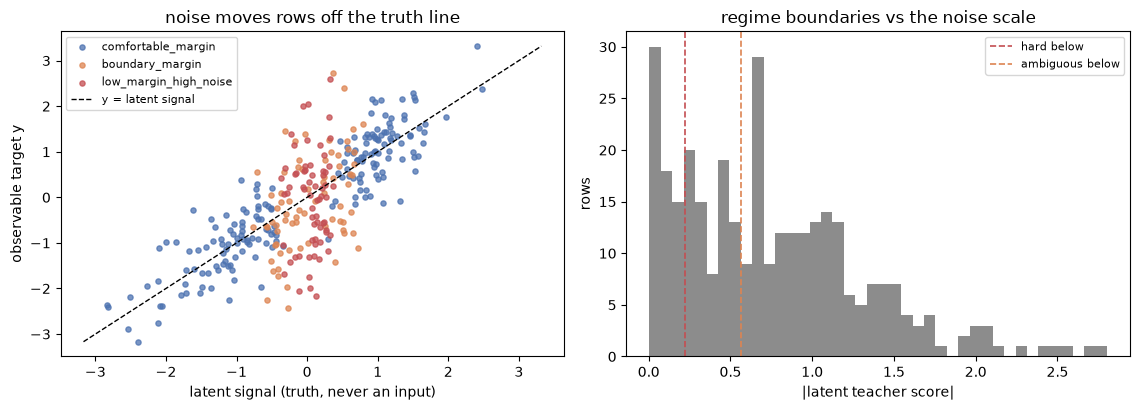

In [4]:
colors = {task.REGIME_EASY: '#4c72b0', task.REGIME_AMBIGUOUS: '#dd8452', task.REGIME_HARD: '#c44e52'}
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11.5, 4.2))
for name in regime_names:
    ax_left.scatter(signal[regime_mask[name]], target[regime_mask[name]], s=14, alpha=0.75, color=colors[name], label=name)
low = float(min(signal.min(), target.min()))
high = float(max(signal.max(), target.max()))
ax_left.plot([low, high], [low, high], color='black', linewidth=1.0, linestyle='--', label='y = latent signal')
ax_left.set_xlabel('latent signal (truth, never an input)')
ax_left.set_ylabel('observable target y')
ax_left.set_title('noise moves rows off the truth line')
ax_left.legend(fontsize=8, loc='upper left')
ax_right.hist(np.abs(score), bins=40, color='#8c8c8c')
for value, name in zip(margin_thresholds, ['hard below', 'ambiguous below']):
    ax_right.axvline(value, color='#c44e52' if name.startswith('hard') else '#dd8452', linestyle='--', linewidth=1.2, label=name)
ax_right.set_xlabel('|latent teacher score|')
ax_right.set_ylabel('rows')
ax_right.set_title('regime boundaries vs the noise scale')
ax_right.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Pre-processing

The split is a seeded permutation: 70% fit rows and 30% evaluation rows, disjoint and covering every generated row. The z-score scaler is fitted on the fit rows only — `fit_scope: train_only` — because fitting on all rows would let evaluation rows influence the transform.

Project choice (derived here, not specified by the papers): the 70/30 fraction, the permutation seed and the z-score transform. The leakage probe below quantifies what an all-rows scaler *would* have done, so the cost of this choice is visible rather than asserted. Both the split and the rows are bound by content hashes; the preprocessing `config_hash` is deliberately the same hash as the task-generation config, so a reader can tie the two artifacts together.

In [5]:
fit_rows, evaluation_rows = preprocess.split_indices(len(rows), CONFIG['seed'], CONFIG['fit_fraction'])
with Timer() as t_preprocess:
    preprocessing = preprocess.build_preprocessing(rows, fit_rows, evaluation_rows)
PREPROCESS_SECONDS = t_preprocess.elapsed

prep_payload = json.dumps(rows, sort_keys=True, separators=(',', ':')).encode()
fit_set = set(preprocessing['fit_rows'])
eval_set = set(preprocessing['evaluation_rows'])

selfcheck(10, bool(fit_set) and bool(eval_set) and fit_set.isdisjoint(eval_set), str(len(fit_set)) + ' fit / ' + str(len(eval_set)) + ' evaluation rows, disjoint')
selfcheck(11, fit_set | eval_set == set(range(len(rows))), 'the split reaches every generated row')
selfcheck(12, preprocessing['fit_scope'] == 'train_only', 'scaler fit scope is train_only')
selfcheck(13, hashlib.sha256(prep_payload).hexdigest() == preprocessing['data_hash'] == truth['data_hash'], 'the published data hash recomputes from the exported rows')
selfcheck(14, preprocessing['config_hash'] == truth['config_hash'] == task.generation_config_hash(), 'preprocessing and generation share one config hash')

feature_columns = preprocessing['scaler']['feature_columns']
recomputed_mean = [float(np.mean([rows[index][column] for index in preprocessing['fit_rows']])) for column in feature_columns]
selfcheck(15, all(abs(a - b) < 1e-12 for a, b in zip(recomputed_mean, preprocessing['scaler']['mean'])), 'every published scaler mean reproduces from the fit rows alone')

print('fit rows / evaluation rows :', len(fit_set), '/', len(eval_set))
print('scaler mean (first 3)      :', [round(value, 4) for value in preprocessing['scaler']['mean'][:3]])
print('scaler std  (first 3)      :', [round(value, 4) for value in preprocessing['scaler']['std'][:3]])
print('leakage probe              : an all-rows scaler would shift feature means by at most', round(preprocessing['leakage_probe']['max_abs_mean_shift'], 4))

SELF-CHECK 10 [MET] 224 fit / 96 evaluation rows, disjoint
SELF-CHECK 11 [MET] the split reaches every generated row
SELF-CHECK 12 [MET] scaler fit scope is train_only
SELF-CHECK 13 [MET] the published data hash recomputes from the exported rows
SELF-CHECK 14 [MET] preprocessing and generation share one config hash
SELF-CHECK 15 [MET] every published scaler mean reproduces from the fit rows alone
fit rows / evaluation rows : 224 / 96
scaler mean (first 3)      : [-0.0063, 0.0213, -0.0747]
scaler std  (first 3)      : [0.9742, 0.9534, 0.9897]
leakage probe              : an all-rows scaler would shift feature means by at most 0.0674


In [6]:
standardized = preprocess.standardize(rows, list(range(len(rows))), preprocessing)
fit_mask = np.zeros(len(rows), dtype=bool)
fit_mask[preprocessing['fit_rows']] = True
feature_x0 = np.asarray([row['x0'] for row in rows], dtype=float)
feature_x1 = np.asarray([row['x1'] for row in rows], dtype=float)
manual = (feature_x0[0] - preprocessing['scaler']['mean'][0]) / preprocessing['scaler']['std'][0]
selfcheck(16, abs(float(manual) - float(standardized[0, 0])) < 1e-12, 'the published scaler reproduces the standardization exactly')

eval_means = standardized[~fit_mask].mean(axis=0)
sampling_band = 5.0 / np.sqrt(float((~fit_mask).sum()))
selfcheck(17, float(np.max(np.abs(eval_means))) <= sampling_band, 'evaluation means after the train-only scaler stay inside the sampling band +/-' + str(round(sampling_band, 3)))

print('fit rows / evaluation rows              :', int(fit_mask.sum()), '/', int((~fit_mask).sum()))
print('standardized evaluation means (first 3) :', [round(float(value), 4) for value in eval_means[:3]])
print('sampling band for those means           : +/-', round(sampling_band, 4))

SELF-CHECK 16 [MET] the published scaler reproduces the standardization exactly
SELF-CHECK 17 [MET] evaluation means after the train-only scaler stay inside the sampling band +/-0.51
fit rows / evaluation rows              : 224 / 96
standardized evaluation means (first 3) : [0.1207, -0.0537, -0.0377]
sampling band for those means           : +/- 0.5103


**How to read this chart.** Left: the two feature axes with fit rows in blue and evaluation rows in orange — the split is a seeded random permutation, so the two clouds overlap by design; what matters is that no evaluation row was used to fit the scaler. Right: the standardized first feature for the two sides after applying the published train-only scaler. The vertical line marks the fit-set mean (zero by construction), and the evaluation histogram is allowed to sit slightly off zero — that small offset is the honest signature of a train-only fit, not a leak.

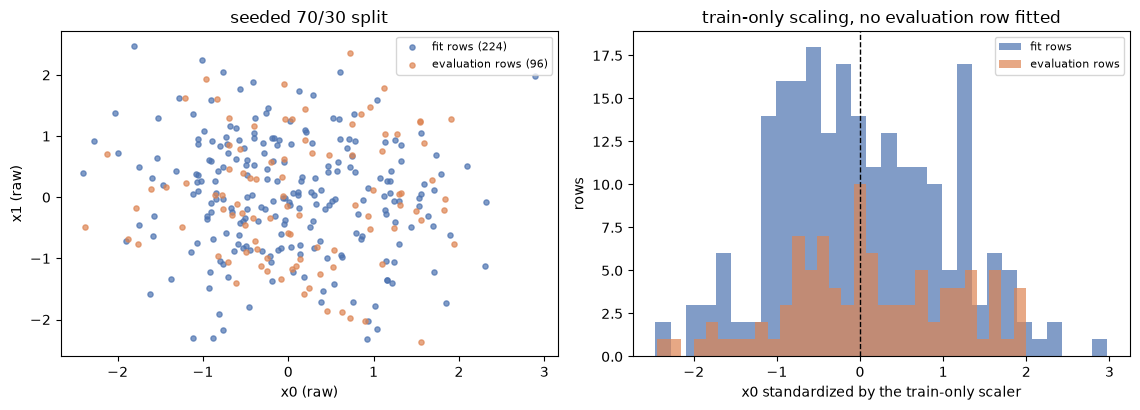

In [7]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax_left.scatter(feature_x0[fit_mask], feature_x1[fit_mask], s=14, alpha=0.7, color='#4c72b0', label='fit rows (224)')
ax_left.scatter(feature_x0[~fit_mask], feature_x1[~fit_mask], s=14, alpha=0.7, color='#dd8452', label='evaluation rows (96)')
ax_left.set_xlabel('x0 (raw)')
ax_left.set_ylabel('x1 (raw)')
ax_left.set_title('seeded 70/30 split')
ax_left.legend(fontsize=8)
ax_right.hist(standardized[fit_mask, 0], bins=30, alpha=0.7, color='#4c72b0', label='fit rows')
ax_right.hist(standardized[~fit_mask, 0], bins=30, alpha=0.7, color='#dd8452', label='evaluation rows')
ax_right.axvline(0.0, color='black', linewidth=1.0, linestyle='--')
ax_right.set_xlabel('x0 standardized by the train-only scaler')
ax_right.set_ylabel('rows')
ax_right.set_title('train-only scaling, no evaluation row fitted')
ax_right.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Training

Two kinds of seeded run carry the telemetry studied in the later stages.

- A paired-seed sweep of **real** minibatch-SGD training: two momentum schedules with the *same* effective learning rate (`eta/(1-rho) = 0.40` for both) are run on the same data, the same initial weights and the same minibatch index schedule, one run per paired seed. Each run records its full loss trace.
- The incident bank: deterministic seeded training traces, each with a decision point, telemetry recorded after that point, and a latent truth kind revealed only after it.

Project choice (derived here, not specified by the papers): the sweep grid (8 paired seeds, 300 steps, batch 16), the incident trace shapes and the detector thresholds. The only *inputs* to the online diagnosis are the telemetry points up to the decision step; the truth kind, the observed outcome and every later point stay out of its reach.

In [8]:
with Timer() as t_sweep:
    sweep_runs = seed_audit.run_sweep()
    audit = seed_audit.build_seed_audit(runs=sweep_runs)
SWEEP_SECONDS = t_sweep.elapsed

bank = incidents.build_bank()
accounting = incidents.account_incidents(bank)
incident_list = bank['incidents']
incident_by_kind = {kind: next(item for item in incident_list if item['truth_kind'] == kind) for kind in sorted(bank['truth_kinds'])}

required_kinds = {'true_divergence', 'recoverable_transient_plateau', 'seed_only_misleading_improvement', 'unresolved_mixed'}
selfcheck(18, required_kinds <= set(bank['truth_kinds']), 'all four incident truth kinds are present')
selfcheck(19, all(any(point['step'] > item['decision_step'] for point in item['telemetry']) for item in incident_list), 'every incident keeps telemetry recorded after its decision step')

divergence = incident_by_kind['true_divergence']
divergence_loss = np.asarray([point['loss'] for point in divergence['telemetry']], dtype=float)
early_median = float(np.median(divergence_loss[:max(2, len(divergence_loss) // 3)]))
selfcheck(20, bool(divergence_loss[-1] > 2.0 * early_median), 'divergence escalates: final ' + f"{divergence_loss[-1]:.2f}" + ' against 2x the early median ' + f"{2.0 * early_median:.2f}")

plateau = incident_by_kind['recoverable_transient_plateau']
plateau_before = [point['loss'] for point in plateau['telemetry'] if point['step'] <= plateau['decision_step']]
plateau_after = [point['loss'] for point in plateau['telemetry'] if point['step'] > plateau['decision_step']]
selfcheck(21, min(plateau_after) < min(plateau_before) and plateau['optimizer_restarted'] is False and plateau['configuration_changed'] is False, 'plateau recovers inside the same run, with no restart and no config change')

selfcheck(22, all(item['online_diagnosis']['label'] in incidents.ONLINE_LABEL_SPACE[item['truth_kind']] for item in incident_list), 'each online label stays inside its allowed vocabulary')

print('incident'.ljust(22), 'truth kind'.ljust(34), 'online label'.ljust(12), 'decision'.rjust(8), 'truth at'.rjust(8))
for item in incident_list:
    print(item['incident_id'].ljust(22), item['truth_kind'].ljust(34), item['online_diagnosis']['label'].ljust(12), str(item['decision_step']).rjust(8), str(item['truth_revealed_after_step']).rjust(8))
print()
print('sweep wall time :', round(SWEEP_SECONDS, 4), 's for', len(audit['config']['seeds']), 'paired seeds x 2 arms x', audit['config']['steps'], 'steps')

SELF-CHECK 18 [MET] all four incident truth kinds are present
SELF-CHECK 19 [MET] every incident keeps telemetry recorded after its decision step
SELF-CHECK 20 [MET] divergence escalates: final 168.40 against 2x the early median 3.97
SELF-CHECK 21 [MET] plateau recovers inside the same run, with no restart and no config change
SELF-CHECK 22 [MET] each online label stays inside its allowed vocabulary
incident               truth kind                         online label decision truth at
inc-divergence-01      true_divergence                    divergence_risk       36       64
inc-plateau-01         recoverable_transient_plateau      wait_for_transient       40       84
inc-seed-only-01       seed_only_misleading_improvement   improving          55       79
inc-mixed-conflict-01  unresolved_mixed                   abstain            34       70
inc-mixed-flat-01      unresolved_mixed                   unresolved         30       60

sweep wall time : 1.2019 s for 8 paired seeds x 2 arm

In [9]:
seed_list = list(audit['config']['seeds'])
arm_curves = {
    'A': np.asarray([sweep_runs[(seed, 'A')]['losses'] for seed in seed_list], dtype=float),
    'B': np.asarray([sweep_runs[(seed, 'B')]['losses'] for seed in seed_list], dtype=float),
}
arm_labels = {arm: audit['config']['arms'][arm]['label'] for arm in ('A', 'B')}
early_window = 80

selfcheck(23, arm_curves['A'].shape == arm_curves['B'].shape == (len(seed_list), audit['config']['steps']), str(len(seed_list)) + ' paired seeds x 2 arms x ' + str(audit['config']['steps']) + ' steps recorded')
selfcheck(24, bool(np.isfinite(arm_curves['A']).all() and np.isfinite(arm_curves['B']).all()), 'every recorded sweep loss is finite')

print('early-window median (first', early_window, 'steps):', {arm: round(float(np.median(arm_curves[arm][:, :early_window])), 4) for arm in ('A', 'B')})
print('final-window median (last 21 steps) :', {arm: round(float(np.median(arm_curves[arm][:, -21:])), 4) for arm in ('A', 'B')})
print('per-seed final metrics              :', {arm: [round(value, 4) for value in audit['per_seed_metrics'][arm]] for arm in ('A', 'B')})

SELF-CHECK 23 [MET] 8 paired seeds x 2 arms x 300 steps recorded
SELF-CHECK 24 [MET] every recorded sweep loss is finite
early-window median (first 80 steps): {'A': 1.111, 'B': 1.245}
final-window median (last 21 steps) : {'A': 1.0513, 'B': 1.0491}
per-seed final metrics              : {'A': [1.0885, 1.1596, 1.0276, 0.9572, 1.2045, 0.7999, 1.0861, 1.0383], 'B': [1.0942, 1.138, 1.0324, 0.9817, 1.2491, 0.7919, 1.0749, 0.9754]}


**How to read this chart.** Each thin line is one paired seed's loss trace for one arm (log scale) and the thick lines are the median across the eight seeds. Both arms see the same data and the same minibatch schedule on a given seed, so a vertical gap at a fixed step is an arm difference while a fan of thin lines is seed noise. The dashed vertical line marks the first 80 steps used by the eyeballed-curve claim later; the ordering visible in that early window does not survive to the end of training.

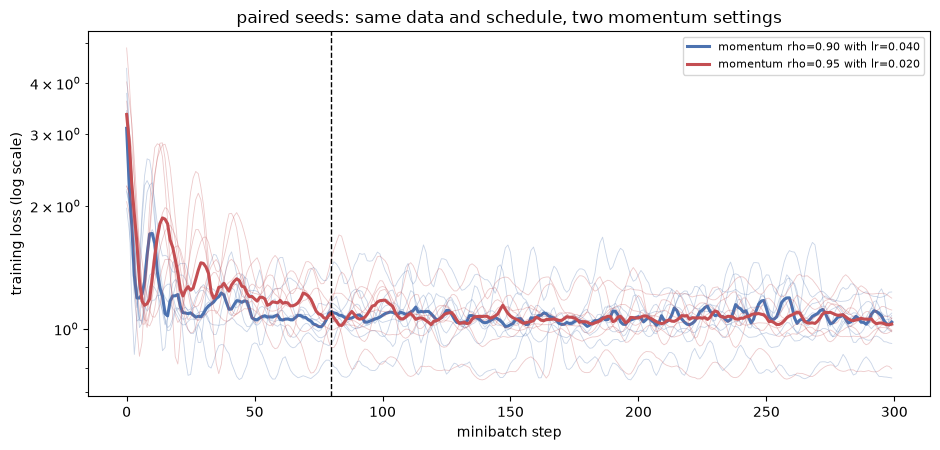

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
arm_colors = {'A': colors[task.REGIME_EASY], 'B': colors[task.REGIME_HARD]}
for arm in ('A', 'B'):
    for curve in arm_curves[arm]:
        ax.plot(curve, color=arm_colors[arm], linewidth=0.6, alpha=0.30)
    ax.plot(np.median(arm_curves[arm], axis=0), color=arm_colors[arm], linewidth=2.2, label=arm_labels[arm])
ax.axvline(early_window, color='black', linewidth=1.0, linestyle='--')
ax.set_yscale('log')
ax.set_xlabel('minibatch step')
ax.set_ylabel('training loss (log scale)')
ax.set_title('paired seeds: same data and schedule, two momentum settings')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Post-training visualization

The charts below are the post-training read. The first shows every incident's loss trace with the decision point and the region that was *not* available when the online call was made. The second shows the seed band from the paired sweep: the median and interquartile range across the eight seeds for each arm.

In [11]:
prefix_lengths = {item['incident_id']: len(item['online_diagnosis']['telemetry_inputs']) for item in incident_list}
future_lengths = {item['incident_id']: sum(1 for point in item['telemetry'] if point['step'] > item['decision_step']) for item in incident_list}

selfcheck(25, all(length > 0 for length in prefix_lengths.values()), 'every stored online diagnosis consumed a non-empty telemetry prefix')
selfcheck(26, all(future_lengths[item['incident_id']] > 0 for item in incident_list), 'every incident has at least one point that was unavailable at decision time')
mixed_labels = sorted(item['online_diagnosis']['label'] for item in incident_list if item['truth_kind'] == 'unresolved_mixed')
selfcheck(27, mixed_labels == ['abstain', 'unresolved'], 'the two unresolved_mixed cases keep distinct honest labels: ' + str(mixed_labels))

print('decision prefix / unseen points per incident:')
for item in incident_list:
    print(' ', item['incident_id'].ljust(22), 'prefix', str(prefix_lengths[item['incident_id']]).rjust(3), ' unseen', str(future_lengths[item['incident_id']]).rjust(3), ' label', item['online_diagnosis']['label'])

SELF-CHECK 25 [MET] every stored online diagnosis consumed a non-empty telemetry prefix
SELF-CHECK 26 [MET] every incident has at least one point that was unavailable at decision time
SELF-CHECK 27 [MET] the two unresolved_mixed cases keep distinct honest labels: ['abstain', 'unresolved']
decision prefix / unseen points per incident:
  inc-divergence-01      prefix  37  unseen  28  label divergence_risk
  inc-plateau-01         prefix  41  unseen  44  label wait_for_transient
  inc-seed-only-01       prefix  56  unseen  24  label improving
  inc-mixed-conflict-01  prefix  35  unseen  36  label abstain
  inc-mixed-flat-01      prefix  31  unseen  30  label unresolved


**How to read this chart.** One panel per incident, with loss on a log scale. The solid vertical line is the decision step and everything to its right is shaded: those points existed only after the online call and were never shown to the detector. Each panel title carries the label the detector actually produced from the unshaded prefix. The divergence panel keeps climbing after its call; the plateau panel is flat at the decision point and recovers later in the same run; the two unresolved_mixed panels are the ones where the honest call is to abstain or to report unresolved evidence.

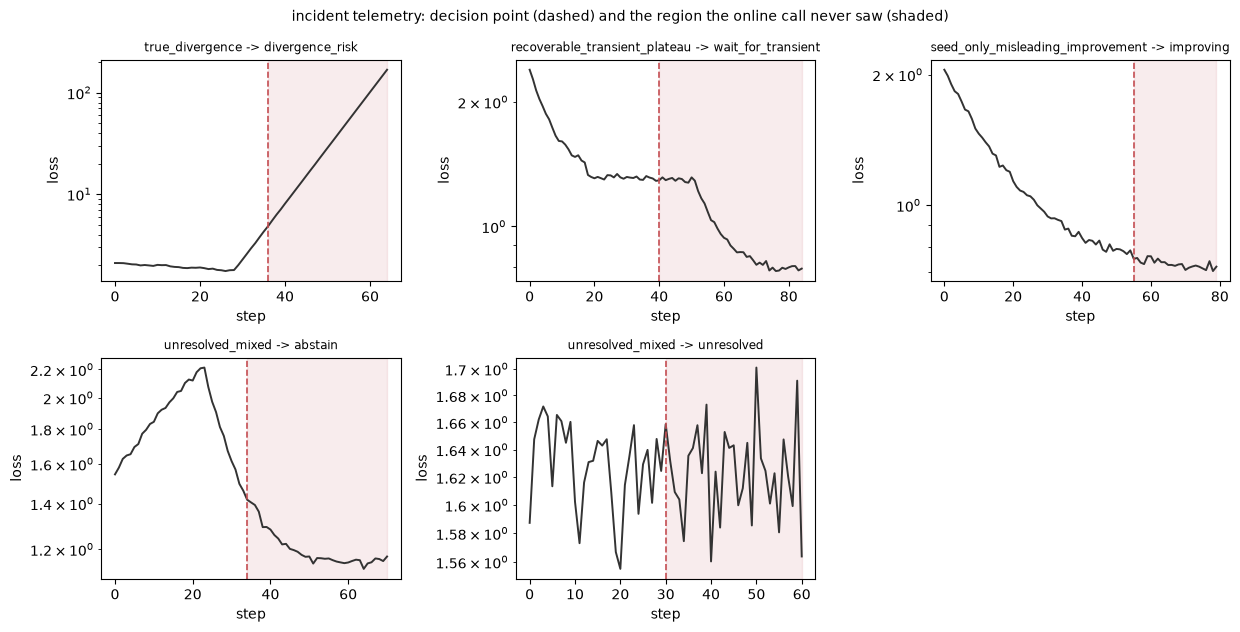

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.4))
axes_flat = list(axes.ravel())
for index, item in enumerate(incident_list):
    axis = axes_flat[index]
    steps = [point['step'] for point in item['telemetry']]
    losses = [point['loss'] for point in item['telemetry']]
    axis.plot(steps, losses, color='#333333', linewidth=1.4)
    axis.axvline(item['decision_step'], color='#c44e52', linewidth=1.2, linestyle='--')
    axis.axvspan(item['decision_step'], max(steps), color='#c44e52', alpha=0.10)
    axis.set_yscale('log')
    axis.set_title(item['truth_kind'] + ' -> ' + item['online_diagnosis']['label'], fontsize=8.5)
    axis.set_xlabel('step')
    axis.set_ylabel('loss')
for axis in axes_flat[len(incident_list):]:
    axis.axis('off')
plt.suptitle('incident telemetry: decision point (dashed) and the region the online call never saw (shaded)', fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
band = audit['seed_band']
band_arrays = {arm: {key: np.asarray(band[arm][key], dtype=float) for key in ('q25', 'median', 'q75')} for arm in ('A', 'B')}
final_step = -1
overlap = min(band_arrays['A']['q75'][final_step], band_arrays['B']['q75'][final_step]) - max(band_arrays['A']['q25'][final_step], band_arrays['B']['q25'][final_step])
selfcheck(28, overlap > 0.0, 'at the final step the arm bands overlap by ' + f"{overlap:.4f}" + ' in loss, so the seeds do not separate the arms')
selfcheck(29, audit['sign_counts']['positive'] > 0 and audit['sign_counts']['negative'] > 0, 'paired differences change sign across seeds: ' + str(audit['sign_counts']))

print('final-step band (q25, median, q75):')
for arm in ('A', 'B'):
    print(' ', arm, [round(float(band_arrays[arm][key][final_step]), 4) for key in ('q25', 'median', 'q75')])
print('paired mean difference:', audit['mean_paired_difference'], ' 95% interval', audit['paired_ci95'])

SELF-CHECK 28 [MET] at the final step the arm bands overlap by 0.0863 in loss, so the seeds do not separate the arms
SELF-CHECK 29 [MET] paired differences change sign across seeds: {'positive': 4, 'negative': 4, 'n_seeds': 8}
final-step band (q25, median, q75):
  A [0.9699, 1.0384, 1.0816]
  B [0.9886, 1.0264, 1.0749]
paired mean difference: -0.003005  95% interval {'low': np.float64(-0.025231), 'high': np.float64(0.019222)}


**How to read this chart.** The shaded ribbon is the interquartile range across the eight paired seeds and the solid line is the seed median, one pair of lines per arm. Where the ribbons overlap, the seeds cannot tell the arms apart; the medians cross partway through training, which is why an eyeballed early-window ranking is a trap. A band describes seed spread; it is not a confidence statement about a winner.

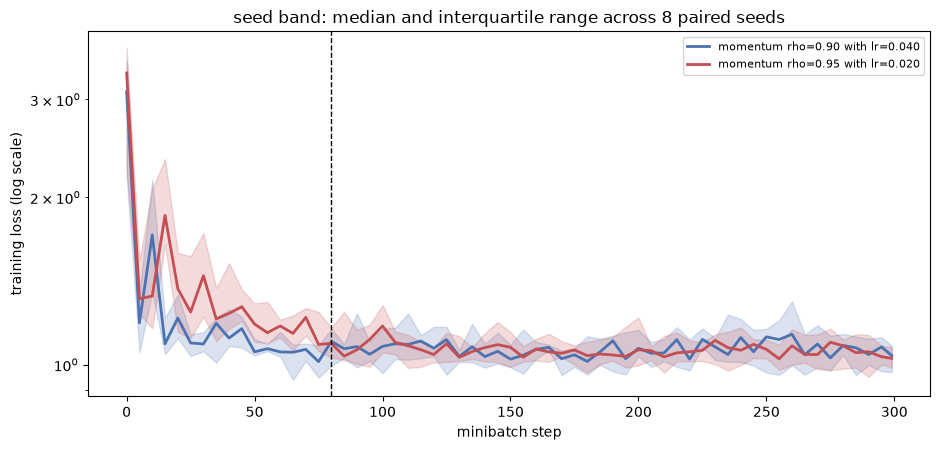

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
band_steps = np.asarray(band['A']['steps'], dtype=int)
for arm in ('A', 'B'):
    arm_color = colors[task.REGIME_EASY] if arm == 'A' else colors[task.REGIME_HARD]
    ax.fill_between(band_steps, band_arrays[arm]['q25'], band_arrays[arm]['q75'], color=arm_color, alpha=0.20)
    ax.plot(band_steps, band_arrays[arm]['median'], color=arm_color, linewidth=2.0, label=arm_labels[arm])
ax.axvline(early_window, color='black', linewidth=1.0, linestyle='--')
ax.set_yscale('log')
ax.set_xlabel('minibatch step')
ax.set_ylabel('training loss (log scale)')
ax.set_title('seed band: median and interquartile range across 8 paired seeds')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Metric observability

This final stage treats the metrics themselves as the object of study.

- **Online diagnosis, replayed.** The detector is re-run on each stored prefix; the call must reproduce without ever touching the truth or the future.
- **Seed audit.** The paired differences, the naive claims they defeat, and the seed-aware summary that keeps the comparison unresolved.
- **Incident accounting.** Abstentions and unresolved cases are counted as their own outcomes and excluded from the accuracy denominator, so they can never be silently scored as correct or incorrect.

Project choice (derived here, not specified by the papers): the label vocabulary, the accounting rule, and the decision to keep every declared seed rather than report a best run.

In [15]:
replay = {item['incident_id']: incidents.diagnose_online(item['online_diagnosis']['telemetry_inputs']) for item in incident_list}
selfcheck(30, all(replay[item['incident_id']] == item['online_diagnosis']['label'] for item in incident_list), 'replaying the detector on every stored prefix reproduces the stored label')
selfcheck(31, all(point['step'] <= item['decision_step'] for item in incident_list for point in item['online_diagnosis']['telemetry_inputs']), 'no stored diagnosis input comes from after its decision step')

short_prefix = [point for point in divergence['telemetry'] if point['step'] <= 12]
early_call = incidents.diagnose_online(short_prefix)
selfcheck(32, early_call in {'abstain', 'unresolved'}, 'with only ' + str(len(short_prefix)) + ' points the detector says ' + early_call + ', instead of guessing a divergence')

leak_blocked = False
try:
    incidents.diagnose_online([dict(point, truth_kind='true_divergence') for point in short_prefix])
except ValueError:
    leak_blocked = True
selfcheck(33, leak_blocked, 'the detector refuses any input that carries hidden truth fields')

paired = audit['paired_seed_differences']
paired_differences = np.asarray([row['difference'] for row in paired], dtype=float)
summary = audit['seed_aware_summary']
selfcheck(34, summary['status'] in {'unresolved', 'tie', 'insufficient_evidence'} and summary['method'] in {'paired_seed_summary', 'seed_band_and_paired_summary'}, 'seed-aware summary keeps ambiguity: ' + summary['status'])
selfcheck(35, all(audit['naive_claims'][name]['claim'] != summary['claim'] for name in audit['naive_claims']), 'every naive claim differs from the seed-aware summary')
selfcheck(36, accounting['outcome_counts'].get('abstain', 0) >= 1 and accounting['outcome_counts'].get('unresolved', 0) >= 1 and accounting['accuracy_denominator_excludes_unresolved'] is True, 'abstentions are visible outcomes, excluded from the accuracy denominator')

print()
print('paired seed differences:')
for row in paired:
    print('  seed', str(row['seed']).rjust(2), 'A', f"{row['arm_a_metric']:.4f}", 'B', f"{row['arm_b_metric']:.4f}", 'difference', f"{row['difference']:+.4f}")
print()
print('naive claims defeated by the audit:')
for name in ('single_seed', 'best_of_n', 'eyeballed_curve'):
    print(' -', name, ':', audit['naive_claims'][name]['claim'])
print()
print('seed-aware summary  :', summary['claim'])
print('incident accounting :', accounting['outcome_counts'], '| denominator excludes unresolved:', accounting['accuracy_denominator_excludes_unresolved'])

SELF-CHECK 30 [MET] replaying the detector on every stored prefix reproduces the stored label
SELF-CHECK 31 [MET] no stored diagnosis input comes from after its decision step
SELF-CHECK 32 [MET] with only 13 points the detector says unresolved, instead of guessing a divergence
SELF-CHECK 33 [MET] the detector refuses any input that carries hidden truth fields
SELF-CHECK 34 [MET] seed-aware summary keeps ambiguity: unresolved
SELF-CHECK 35 [MET] every naive claim differs from the seed-aware summary
SELF-CHECK 36 [MET] abstentions are visible outcomes, excluded from the accuracy denominator

paired seed differences:
  seed  0 A 1.0885 B 1.0942 difference +0.0057
  seed  1 A 1.1596 B 1.1380 difference -0.0217
  seed  2 A 1.0276 B 1.0324 difference +0.0048
  seed  3 A 0.9572 B 0.9817 difference +0.0246
  seed  4 A 1.2045 B 1.2491 difference +0.0447
  seed  5 A 0.7999 B 0.7919 difference -0.0079
  seed  6 A 1.0861 B 1.0749 difference -0.0112
  seed  7 A 1.0383 B 0.9754 difference -0.0629

n

In [16]:
ci = audit['paired_ci95']
mean_difference = audit['mean_paired_difference']
distinct_seeds = len({row['seed'] for row in paired})
selfcheck(37, len(paired) >= 2 and distinct_seeds >= 2, str(len(paired)) + ' paired differences over ' + str(distinct_seeds) + ' distinct seeds')
selfcheck(38, bool(np.any(paired_differences > 0) and np.any(paired_differences < 0)), 'paired differences contain both signs')

print('bars to draw (seed, difference):', [(row['seed'], row['difference']) for row in paired])
print('paired mean difference:', mean_difference, ' 95% interval:', ci)
print('the single-seed naive claim would pick seed', paired[0]['seed'], 'with difference', paired[0]['difference'])
print('the best-of-3 naive claim would pick:', audit['naive_claims']['best_of_n']['claim'])

SELF-CHECK 37 [MET] 8 paired differences over 8 distinct seeds
SELF-CHECK 38 [MET] paired differences contain both signs
bars to draw (seed, difference): [(0, 0.005687), (1, -0.02167), (2, 0.004834), (3, 0.024559), (4, 0.044651), (5, -0.00794), (6, -0.011209), (7, -0.062949)]
paired mean difference: -0.003005  95% interval: {'low': np.float64(-0.025231), 'high': np.float64(0.019222)}
the single-seed naive claim would pick seed 0 with difference 0.005687
the best-of-3 naive claim would pick: best-of-3 runs: arm A reaches 1.0276 at seed 2, 0.47% below arm B, so A wins


**How to read this chart.** Each bar is one paired seed's difference between the two arms (arm B minus arm A), so bars above zero favour arm A and bars below zero favour arm B. The two colours make the sign change visible at a glance: a single-seed protocol would report whichever bar it happened to land on, and a best-of-N protocol would report the shortest bar. The horizontal band is the 95% interval for the paired mean difference; it crosses zero, which is why the audit reports the comparison as unresolved instead of picking a winner.

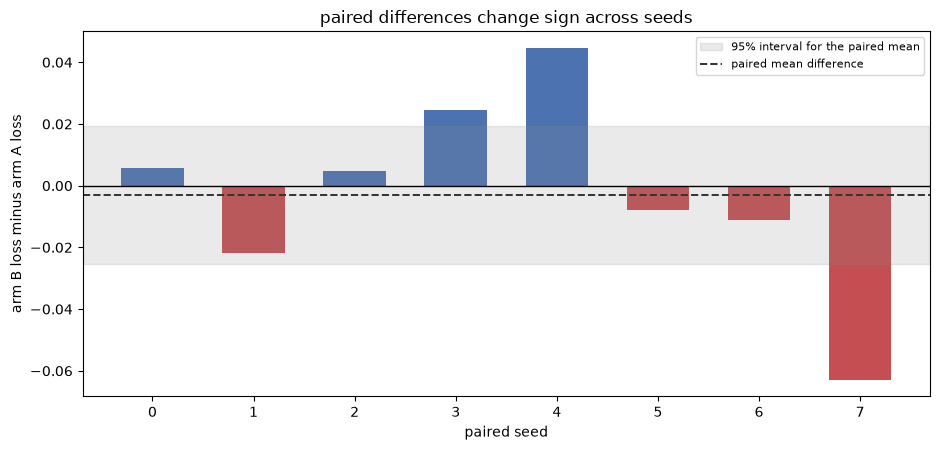

In [17]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
bar_colors = [colors[task.REGIME_EASY] if value > 0 else colors[task.REGIME_HARD] for value in paired_differences]
positions = np.arange(len(paired))
ax.bar(positions, paired_differences, color=bar_colors, width=0.62)
ax.axhline(0.0, color='black', linewidth=1.0)
ax.axhspan(ci['low'], ci['high'], color='#8c8c8c', alpha=0.18, label='95% interval for the paired mean')
ax.axhline(mean_difference, color='#333333', linewidth=1.4, linestyle='--', label='paired mean difference')
ax.set_xticks(positions)
ax.set_xticklabels([str(row['seed']) for row in paired])
ax.set_xlabel('paired seed')
ax.set_ylabel('arm B loss minus arm A loss')
ax.set_title('paired differences change sign across seeds')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
# ---- two more generations: one exact repeat, one different seed
with Timer() as t_repeat:
    repeat_rows = task.generate_rows(CONFIG)
REPEAT_SECONDS = t_repeat.elapsed
repeat_hash = task.dataset_data_hash(repeat_rows)
with Timer() as t_alt:
    alt_rows = task.generate_rows({**CONFIG, 'seed': CONFIG['seed'] + 1})
ALT_SECONDS = t_alt.elapsed
alt_config_hash = sha256_json({**CONFIG, 'seed': CONFIG['seed'] + 1})
alt_hash = task.dataset_data_hash(alt_rows)

reproducibility = {
    'repeated_runs': [
        {'seed': CONFIG['seed'], 'config_hash': truth['config_hash'], 'data_hash': truth['data_hash'], 'attempt': 'primary'},
        {'seed': CONFIG['seed'], 'config_hash': truth['config_hash'], 'data_hash': repeat_hash, 'attempt': 'repeat_same_seed_same_config'},
        {'seed': CONFIG['seed'] + 1, 'config_hash': alt_config_hash, 'data_hash': alt_hash, 'attempt': 'different_seed_sanity'},
    ],
    'note': 'the two same-seed runs agree on the data hash; the different-seed run is recorded to show that the hash is seed-sensitive',
}

# ---- publish: merge, so keys written by a later notebook are never lost
published_path = PROJECT_ROOT / 'exec' / 'walkthrough_results.json'
published = load_json(published_path, {}) or {}
published.update({
    'task_truth': truth,
    'preprocessing': preprocessing,
    'reproducibility': reproducibility,
    'incident_bank': bank,
    'seed_audit': audit,
    'incident_accounting': accounting,
})
write_json(published_path, published)

# ---- ledger rows, appended through the frozen helper (merge-by-run_id)
generation_result = {
    'n_rows': len(rows),
    'task_kind': truth['task_kind'],
    'signal_strength': truth['signal_strength'],
    'data_hash': truth['data_hash'],
    'config_hash': truth['config_hash'],
    'external_hash_recomputation': external_style_hash,
}
repeat_result = {
    'data_hash': repeat_hash,
    'matches_first_generation': repeat_hash == truth['data_hash'],
    'n_rows': len(repeat_rows),
}
sweep_result = {
    'n_seeds': len(audit['config']['seeds']),
    'sign_counts': audit['sign_counts'],
    'mean_paired_difference': audit['mean_paired_difference'],
    'status': audit['seed_aware_summary']['status'],
    'data_hash': audit['data_hash'],
    'config_hash': audit['config_hash'],
}
append_runs([
    make_run('nb2-task-generation', '02', CONFIG['seed'], truth['data_hash'], truth['config_hash'], generation_result, GENERATION_SECONDS),
    make_run('nb2-task-generation-repeat', '02', CONFIG['seed'], repeat_hash, truth['config_hash'], repeat_result, REPEAT_SECONDS),
    make_run('nb2-training-sweep', '02', audit['config']['seed'], audit['data_hash'], audit['config_hash'], sweep_result, SWEEP_SECONDS),
])

# ---- cached rerun: a real cache read of the published rows, history preserved
with Timer() as t_cache:
    cached_rows = pipeline.load_dataset()
    cache_verified = task.dataset_data_hash(cached_rows) == truth['data_hash']
CACHE_SECONDS = t_cache.elapsed
ledger_index = {row['run_id']: row for row in load_ledger()}
original_row = ledger_index['nb2-task-generation']
CACHE_COST_FLOOR_USD = 1e-7
cache_cost = max(round(CACHE_SECONDS * ASSUMED_USD_PER_GPU_HOUR / 3600.0, 12), CACHE_COST_FLOOR_USD)
append_runs([
    make_run(
        'nb2-task-generation-cached', '02', original_row['seed'], original_row['data_hash'], original_row['config_hash'],
        {'cache_status': 'cached_rerun', 'reuses_run_id': 'nb2-task-generation', 'n_rows': len(cached_rows), 'cache_verified': cache_verified},
        CACHE_SECONDS,
        assumed_cost_usd=cache_cost,
        cache_status='cached_rerun',
        reuses_run_id='nb2-task-generation',
        historical_wall_time_s=original_row['wall_time_s'],
        historical_assumed_cost_usd=original_row['assumed_cost_usd'],
    )
])

final_published = load_json(published_path, {}) or {}
ledger_after = {row['run_id']: row for row in load_ledger()}
cached_row = ledger_after['nb2-task-generation-cached']
original_after = ledger_after['nb2-task-generation']
selfcheck(39, all(key in final_published for key in ('task_truth', 'preprocessing', 'reproducibility', 'incident_bank', 'seed_audit', 'incident_accounting')), 'walkthrough_results.json carries every NB2 key')
selfcheck(40, bool(cache_verified) and repeat_hash == truth['data_hash'], 'the repeat generation reproduces the data hash and the cached rows verify against it')
selfcheck(41, cached_row['assumed_cost_usd'] > 0 and cached_row['historical_assumed_cost_usd'] > 0 and cached_row['historical_wall_time_s'] == original_after['wall_time_s'], 'the cached rerun keeps a nonzero cost and the original wall-clock and cost history')

print()
print('published keys  :', sorted(final_published))
print('ledger run ids  :', sorted(ledger_after))
print('cache hit cost  :', cached_row['assumed_cost_usd'], 'USD, with historical', cached_row['historical_assumed_cost_usd'], 'USD kept')
print('cost assumption :', COST_ASSUMPTION)

SELF-CHECK 39 [MET] walkthrough_results.json carries every NB2 key
SELF-CHECK 40 [MET] the repeat generation reproduces the data hash and the cached rows verify against it
SELF-CHECK 41 [MET] the cached rerun keeps a nonzero cost and the original wall-clock and cost history

published keys  : ['incident_accounting', 'incident_bank', 'preprocessing', 'reproducibility', 'seed_audit', 'task_truth']
ledger run ids  : ['nb2-task-generation', 'nb2-task-generation-cached', 'nb2-task-generation-repeat', 'nb2-training-sweep']
cache hit cost  : 2.2615572e-05 USD, with historical 2.89414e-05 USD kept
cost assumption : assumed cost = wall-clock seconds x USD 1.50 per GPU-hour (a stated T4-class cloud-rate assumption, not a measured invoice)


**What this notebook deliberately does not decide — limitations.**

- The detector thresholds are project choices derived here, not constants from the papers; keeping them, retuning them for another regime mix, or replacing the detector entirely are all left open.
- The paired-seed audit is deliberately unresolved: no paired-seed power calculation is made, so this design cannot certify a winner, and a minimum detectable effect is not computed. How many paired seeds a claim like this would need, and what effect size is worth chasing, is left open.
- Nothing here transfers to adaptive optimizers, non-quadratic losses, or financial time-series data; those transfers are open questions, not results.
- The 1.50 USD per GPU-hour rate in the ledger is a stated assumption, not a measurement; operational cost on real hardware is not claimed.
- No production false-alarm or miss-rate guarantee is offered: a quiet detector is not a safety certificate, and this is a synthetic portfolio starting point, not production evidence.
- Seed counts in the papers are conditional to their own protocol (not a universal requirement), and the PLK boundary stays order-level: an exact constant is not claimed here.

The two artifacts this notebook writes are `exec/walkthrough_results.json` (merged, so a later notebook can add to it) and its rows in `exec/run_ledger.json`; the next notebook in the portfolio reuses this pipeline through `exec/walkthrough/pipeline.py` rather than re-deriving the task; that reuse is itself worth reviewing on its own terms.